# Belief Stickiness in Consumer Durable Goods Expectations
## v3 - Option B (Choice 2): LASSO targets realized spending
**MQE Capstone - Tanishq Tiwari, UCLA**

**What is different from v1 and v2:**
- **LASSO target changed:** the rational benchmark is now constructed by predicting **real PCE durable goods growth** from macro variables, NOT the subjective belief itself. This aligns the rational benchmark with the realized outcome (the Du et al. 2025 framework spirit) and avoids the previous circularity in which the LASSO partially absorbed the sticky component of beliefs.
- **Stickiness re-defined as a standardized z-score gap:** because the subjective belief (an index) and the LASSO forecast (a growth rate) live on different scales, both are standardized over the sample and stickiness is the gap in standardized units:
$$S_t = z(\text{UMSBMQ}_t) - z(\hat{c}_t)$$
This series is reported descriptively (chart + persistence). The formal test of consequences is in the predictive regression.
- **Predictive regression has a new structure:** spending growth at $t+h$ is regressed on the LASSO forecast $\hat{c}_t$, the subjective belief $\text{UMSBMQ}_t$, and controls. The coefficient $\beta_2$ on the subjective belief identifies whether beliefs carry information beyond what fundamentals predict ? this is the "stickiness has consequences" test.
- The asymmetric (pessimism-specific) variant splits the belief into deviations above and below its mean.

**Three samples reported throughout:** Full / No COVID / No abnormal.


## Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
import matplotlib.pyplot as plt
import statsmodels.api as sm

DATA_DIR = Path(r"C:\Users\tanis\OneDrive\Desktop\capstone\tt_capstone")
OUT_DIR = DATA_DIR / "outputs"
FIG_DIR = DATA_DIR / "figures"
OUT_DIR.mkdir(exist_ok=True)
FIG_DIR.mkdir(exist_ok=True)

SAMPLE_START = "1997-01-01"
SAMPLE_END = "2024-12-01"
ROLLING_WINDOW = 120

In [2]:
def load_fred(filename, col_name=None):
    d = pd.read_csv(DATA_DIR / filename)
    d['observation_date'] = pd.to_datetime(d['observation_date'])
    d = d.rename(columns={'observation_date': 'date'}).set_index('date').sort_index()
    if col_name is not None and d.columns[0] != col_name:
        d.columns = [col_name]
    return d

def yoy(s, periods=12):
    return s.pct_change(periods) * 100

## Stage 1 - Load data

In [3]:
# Subjective belief: UMich Index of Buying Conditions for Large Durables.
umsbmq_raw = pd.read_csv(DATA_DIR / 'sca-table35-on-2026-Apr-30.csv', skiprows=1)
umsbmq_raw.columns = umsbmq_raw.columns.str.strip()
umsbmq_raw['date'] = pd.to_datetime(
    umsbmq_raw['Year'].astype(str) + '-' +
    umsbmq_raw['Month'].astype(str).str.zfill(2) + '-01',
    errors='coerce'
)
umsbmq = (umsbmq_raw.dropna(subset=['date'])
                    [['date', 'Relative']]
                    .rename(columns={'Relative': 'UMSBMQ'})
                    .set_index('date').sort_index())
umsbmq['UMSBMQ'] = pd.to_numeric(umsbmq['UMSBMQ'], errors='coerce')
print(f"UMSBMQ: {umsbmq.index.min().date()} to {umsbmq.index.max().date()}, n={len(umsbmq)}")

UMSBMQ: 1978-01-01 to 2026-03-01, n=579


In [4]:
monthly = pd.read_csv(DATA_DIR / 'monthly.csv')
monthly['observation_date'] = pd.to_datetime(monthly['observation_date'])
monthly = monthly.rename(columns={'observation_date': 'date'}).set_index('date').sort_index()

daily = pd.read_csv(DATA_DIR / 'daily.csv')
daily['observation_date'] = pd.to_datetime(daily['observation_date'])
daily['DGS10'] = pd.to_numeric(daily['DGS10'], errors='coerce')
daily = daily.set_index('observation_date').sort_index()
dgs10 = daily.resample('MS').mean(); dgs10.index.name = 'date'

t10y2y = load_fred('T10Y2Y (1).csv', 'T10Y2Y')
psavert = load_fred('PSAVERT.csv', 'PSAVERT')

quarterly = pd.read_csv(DATA_DIR / 'quarterly.csv')
quarterly['observation_date'] = pd.to_datetime(quarterly['observation_date'])
quarterly = quarterly.rename(columns={'observation_date': 'date'}).set_index('date').sort_index()
gdp_growth = quarterly[['A191RL1Q225SBEA']].resample('MS').ffill()

pcepi = load_fred('PCEPI.csv', 'PCEPI');            pcepi['PCEPI_YOY']      = yoy(pcepi['PCEPI'])
dspic = load_fred('DSPIC96.csv', 'DSPIC96');        dspic['DSPIC96_YOY']    = yoy(dspic['DSPIC96'])
cpilfesl = load_fred('CPILFESL.csv', 'CPILFESL');   cpilfesl['CPILFESL_YOY'] = yoy(cpilfesl['CPILFESL'])
cusr = load_fred('CUSR0000SAD.csv', 'CUSR0000SAD'); cusr['CUSR0000SAD_YOY'] = yoy(cusr['CUSR0000SAD'])
ppifis = load_fred('PPIFIS.csv', 'PPIFIS');         ppifis['PPIFIS_YOY']    = yoy(ppifis['PPIFIS'])
ir41 = load_fred('IR41.csv', 'IR41');               ir41['IR41_YOY']        = yoy(ir41['IR41'])

deflator = load_fred('DDURRD3Q086SBEA.csv', 'DDURRD3Q086SBEA')
deflator['DDURRD_YOY'] = yoy(deflator['DDURRD3Q086SBEA'], periods=4)
deflator_m = deflator[['DDURRD_YOY']].resample('MS').ffill()

# Construct REAL PCE durables YoY (deflate nominal PCEDG by durables CPI)
pcedg = load_fred('PCEDG.csv', 'PCEDG')
combined_dur = pd.concat([pcedg['PCEDG'], cusr['CUSR0000SAD']], axis=1).dropna()
combined_dur['real_PCEDG'] = combined_dur['PCEDG'] / combined_dur['CUSR0000SAD'] * 100
combined_dur['PCE_Durables_Real_YoY'] = combined_dur['real_PCEDG'].pct_change(12) * 100
real_dur = combined_dur[['PCE_Durables_Real_YoY']]

pcnd = load_fred('PCND.csv', 'PCND'); pcnd['PCND_YOY'] = yoy(pcnd['PCND'], periods=4)
pcnd_m = pcnd[['PCND_YOY']].resample('MS').ffill().rename(columns={'PCND_YOY':'PCE_NonDurables_YoY'})
print("All sources loaded.")

All sources loaded.


## Stage 2 - Publication lags, merge & rename

In [5]:
lag1_cols = ['CPIAUCSL_PC1', 'INDPRO_PC1', 'MANEMP_PC1', 'RSXFS_PC1', 'UNRATE',
             'MICH', 'UMCSENT', 'HOUST']
lag2_cols = ['DGORDER_PC1']

monthly_lag = monthly.copy()
for c in lag1_cols: monthly_lag[c] = monthly_lag[c].shift(1)
for c in lag2_cols: monthly_lag[c] = monthly_lag[c].shift(2)

others_1m = pd.concat([
    psavert.shift(1), pcepi[['PCEPI_YOY']].shift(1), dspic[['DSPIC96_YOY']].shift(1),
    cpilfesl[['CPILFESL_YOY']].shift(1), cusr[['CUSR0000SAD_YOY']].shift(1),
    ppifis[['PPIFIS_YOY']].shift(1), ir41[['IR41_YOY']].shift(1),
], axis=1)

gdp_lag = gdp_growth.shift(3); deflator_lag = deflator_m.shift(3)
fin = pd.concat([dgs10[['DGS10']], t10y2y], axis=1)

# Real durables enters with NO LAG because it is now the LASSO target (contemporaneous t)
merged_full = pd.concat(
    [monthly_lag, fin, others_1m, gdp_lag, deflator_lag, real_dur, umsbmq],
    axis=1
).sort_index()
merged_full.index.name = 'date'

RENAME = {
    'CPIAUCSL_PC1':'CPI_YoY','DGORDER_PC1':'DurableOrders_YoY','FEDFUNDS':'FedFundsRate',
    'HOUST':'HousingStarts','INDPRO_PC1':'IndProduction_YoY','MANEMP_PC1':'MfgEmployment_YoY',
    'MICH':'InflExpect_1yr','RSXFS_PC1':'RetailSales_YoY','UMCSENT':'ConsumerSentiment',
    'UNRATE':'UnemploymentRate','DGS10':'Treasury10Y','T10Y2Y':'YieldSpread_10Y_2Y',
    'PSAVERT':'PersonalSavingRate','PCEPI_YOY':'PCE_Infl_YoY','DSPIC96_YOY':'RealDispIncome_YoY',
    'CPILFESL_YOY':'CoreCPI_YoY','CUSR0000SAD_YOY':'DurablesCPI_YoY','PPIFIS_YOY':'PPI_FinalDemand_YoY',
    'IR41_YOY':'ImportPrices_Durables_YoY','DDURRD_YOY':'DurablesDeflator_YoY',
    'A191RL1Q225SBEA':'RealGDP_Growth','UMSBMQ':'DurableBuyingConditions',
}
merged_full = merged_full.rename(columns=RENAME)
merged_full.to_csv(OUT_DIR / 'merged_full_v3.csv')

df = merged_full.loc[SAMPLE_START:SAMPLE_END].copy()
df.to_csv(OUT_DIR / 'merged_sample_v3.csv')
print(f"Sample panel: {df.index.min().date()} to {df.index.max().date()}, n={len(df)}")
print("Has PCE_Durables_Real_YoY (LASSO target):", 'PCE_Durables_Real_YoY' in df.columns)
print("Has DurableBuyingConditions (subjective belief):", 'DurableBuyingConditions' in df.columns)

Sample panel: 1997-01-01 to 2024-12-01, n=336
Has PCE_Durables_Real_YoY (LASSO target): True
Has DurableBuyingConditions (subjective belief): True


## Stage 2b - Outlier detection

Same data-driven rule as v2: flag months where any of `UnemploymentRate`, `IndProduction_YoY`,
or `RetailSales_YoY` exceeds |z|>3 over the sample.


In [6]:
ind_cols = ['UnemploymentRate', 'IndProduction_YoY', 'RetailSales_YoY']
z = (df[ind_cols] - df[ind_cols].mean()) / df[ind_cols].std()
all_outliers = df.index[z.abs().max(axis=1) > 3]

covid_outliers = pd.DatetimeIndex([
    '2020-05-01', '2020-06-01', '2021-04-01', '2021-05-01', '2021-06-01'
])

print(f"All |z|>3 outliers ({len(all_outliers)} months):")
for d in all_outliers:
    zu, zi, zr = z.loc[d, ind_cols]
    print(f"  {d.date()}  UNRATE z={zu:+.2f}  INDPRO z={zi:+.2f}  RSXFS z={zr:+.2f}")
print(f"\nCOVID subset ({len(covid_outliers)} months): {list(covid_outliers.strftime('%Y-%m'))}")

All |z|>3 outliers (14 months):
  2008-12-01  UNRATE z=+0.65  INDPRO z=-2.20  RSXFS z=-3.15
  2009-01-01  UNRATE z=+0.91  INDPRO z=-2.78  RSXFS z=-3.37
  2009-02-01  UNRATE z=+1.18  INDPRO z=-3.25  RSXFS z=-3.14
  2009-03-01  UNRATE z=+1.44  INDPRO z=-3.30  RSXFS z=-3.06
  2009-04-01  UNRATE z=+1.65  INDPRO z=-3.54  RSXFS z=-3.42
  2009-05-01  UNRATE z=+1.81  INDPRO z=-3.58  RSXFS z=-3.31
  2009-06-01  UNRATE z=+2.03  INDPRO z=-3.65  RSXFS z=-3.31
  2009-07-01  UNRATE z=+2.08  INDPRO z=-3.68  RSXFS z=-3.03
  2009-08-01  UNRATE z=+2.08  INDPRO z=-3.40  RSXFS z=-2.86
  2020-05-01  UNRATE z=+4.89  INDPRO z=-4.14  RSXFS z=-3.92
  2020-06-01  UNRATE z=+4.04  INDPRO z=-3.85  RSXFS z=-1.06
  2021-04-01  UNRATE z=+0.28  INDPRO z=-0.03  RSXFS z=+4.74
  2021-05-01  UNRATE z=+0.28  INDPRO z=+3.45  RSXFS z=+8.36
  2021-06-01  UNRATE z=+0.12  INDPRO z=+3.26  RSXFS z=+3.62

COVID subset (5 months): ['2020-05', '2020-06', '2021-04', '2021-05', '2021-06']


In [7]:
samples = {
    'Full':         df.index,
    'No COVID':     df.index.difference(covid_outliers),
    'No abnormal':  df.index.difference(all_outliers),
}
panels = {
    'Full':         merged_full,
    'No COVID':     merged_full.drop(covid_outliers,  errors='ignore'),
    'No abnormal':  merged_full.drop(all_outliers,    errors='ignore'),
}
for name, idx in samples.items():
    print(f"  {name:14s}: {len(idx)} months, training panel = {len(panels[name])} rows")

  Full          : 336 months, training panel = 953 rows
  No COVID      : 331 months, training panel = 948 rows
  No abnormal   : 322 months, training panel = 939 rows


## Stage 3 - Rolling LASSO predicting REAL PCE durables growth

At each month $t$, fit `LassoCV` on the previous 120 months to predict **real PCE durable goods
growth at time $t$** from 21 macro variables (all standardized, with publication lags applied).

**Key change from v1/v2:** the target is now the realized spending outcome, not the subjective
belief. The fitted value $\hat{c}_t$ represents what macroeconomic fundamentals predict
contemporaneous spending growth should be.


In [8]:
PREDICTORS = [
    'CPI_YoY', 'DurableOrders_YoY', 'FedFundsRate', 'HousingStarts', 'IndProduction_YoY',
    'MfgEmployment_YoY', 'InflExpect_1yr', 'RetailSales_YoY', 'ConsumerSentiment', 'UnemploymentRate',
    'Treasury10Y', 'YieldSpread_10Y_2Y', 'PersonalSavingRate',
    'PCE_Infl_YoY', 'RealDispIncome_YoY', 'CoreCPI_YoY', 'DurablesCPI_YoY',
    'PPI_FinalDemand_YoY', 'ImportPrices_Durables_YoY', 'DurablesDeflator_YoY', 'RealGDP_Growth'
]
TARGET = 'PCE_Durables_Real_YoY'   # <-- now the realized outcome
print(f"Candidate predictors (N={len(PREDICTORS)})")
print(f"LASSO target: {TARGET}")

Candidate predictors (N=21)
LASSO target: PCE_Durables_Real_YoY


In [9]:
def lasso_oos(window_df, target, predictors):
    """Out-of-sample rolling LASSO: train on t-120..t-1, predict at t."""
    valid = [p for p in predictors if window_df[p].notna().all()]
    if len(valid) < 3:
        return np.nan, valid, [], np.nan
    w = window_df[[target] + valid].dropna()
    if len(w) < 60:
        return np.nan, valid, [], np.nan
    train, test_row = w.iloc[:-1], w.iloc[[-1]]
    if len(train) < 60:
        return np.nan, valid, [], np.nan
    scaler = StandardScaler().fit(train[valid].values)
    Xs = scaler.transform(train[valid].values)
    tscv = TimeSeriesSplit(n_splits=5)
    lasso = LassoCV(cv=tscv, max_iter=20000, n_alphas=100, random_state=42).fit(Xs, train[target].values)
    pred = float(lasso.predict(scaler.transform(test_row[valid].values))[0])
    selected = [p for p, c in zip(valid, lasso.coef_) if abs(c) > 1e-8]
    return pred, valid, selected, float(lasso.alpha_)

def run_rolling(name, sample_dates, panel):
    chat = pd.Series(index=sample_dates, dtype=float)
    nvalid = pd.Series(index=sample_dates, dtype='Int64')
    nsel = pd.Series(index=sample_dates, dtype='Int64')
    alphas = pd.Series(index=sample_dates, dtype=float)
    log = []
    print(f"--- {name} ({len(sample_dates)} predict-months) ---")
    for i, t in enumerate(sample_dates):
        win = panel.loc[t - pd.DateOffset(months=ROLLING_WINDOW - 1):t]
        pred, valid, sel, a = lasso_oos(win, TARGET, PREDICTORS)
        chat.loc[t] = pred; nvalid.loc[t] = len(valid); nsel.loc[t] = len(sel); alphas.loc[t] = a
        log.append({'date': t, 'selected': sel})
        if (i + 1) % 80 == 0 or i == len(sample_dates) - 1:
            print(f"  {t.date()}  ({i+1}/{len(sample_dates)})  valid={len(valid):2d} selected={len(sel):2d}")
    return chat, nvalid, nsel, alphas, log

In [10]:
# SLOW CELL (~10-12 min total: three LASSO sweeps)
results = {}
logs = {}
for name, sample_dates in samples.items():
    chat, nv, ns, al, log = run_rolling(name, sample_dates, panels[name])
    r = pd.DataFrame({
        'B_subjective':  df.loc[sample_dates, 'DurableBuyingConditions'],
        'c_hat':         chat,
        'actual_dur':    df.loc[sample_dates, TARGET],
    })
    r['n_valid'] = nv; r['n_selected'] = ns; r['alpha'] = al
    results[name] = r
    logs[name] = log
    fname = f"v3_lasso_forecast_{name.lower().replace(' ', '_')}.csv"
    r.to_csv(OUT_DIR / fname)
    print(f"  saved -> {fname}")

--- Full (336 predict-months) ---
  2003-08-01  (80/336)  valid=20 selected=11
  2010-04-01  (160/336)  valid=20 selected= 4
  2016-12-01  (240/336)  valid=20 selected= 7
  2023-08-01  (320/336)  valid=21 selected=12
  2024-12-01  (336/336)  valid=21 selected= 6
  saved -> v3_lasso_forecast_full.csv
--- No COVID (331 predict-months) ---
  2003-08-01  (80/331)  valid=20 selected=11
  2010-04-01  (160/331)  valid=20 selected= 4
  2016-12-01  (240/331)  valid=20 selected= 7
  2024-01-01  (320/331)  valid=21 selected= 4
  2024-12-01  (331/331)  valid=21 selected= 7
  saved -> v3_lasso_forecast_no_covid.csv
--- No abnormal (322 predict-months) ---
  2003-08-01  (80/322)  valid=20 selected=11
  2011-01-01  (160/322)  valid=20 selected= 6
  2017-09-01  (240/322)  valid=20 selected= 8
  2024-10-01  (320/322)  valid=21 selected=10
  2024-12-01  (322/322)  valid=21 selected= 7
  saved -> v3_lasso_forecast_no_abnormal.csv


In [11]:
# Predictor selection comparison
def sel_pct(log):
    counts = pd.Series(0, index=PREDICTORS, dtype=int)
    for row in log:
        for p in row['selected']:
            counts[p] += 1
    return counts / len(log) * 100

sel_compare = pd.DataFrame({name: sel_pct(logs[name]) for name in samples}).round(1)
print("Predictor selection frequency when LASSO predicts real durables growth (% of months):")
print(sel_compare.sort_values('Full', ascending=False).to_string())

Predictor selection frequency when LASSO predicts real durables growth (% of months):
                           Full  No COVID  No abnormal
RealGDP_Growth             78.0      73.4         59.3
RetailSales_YoY            75.6      72.2         70.5
ConsumerSentiment          68.8      70.7         68.6
DurablesDeflator_YoY       57.7      56.2         48.8
CPI_YoY                    53.6      53.8         55.9
CoreCPI_YoY                53.3      55.3         55.0
IndProduction_YoY          51.5      48.6         50.3
RealDispIncome_YoY         51.5      50.2         49.1
Treasury10Y                45.8      41.4         36.3
PCE_Infl_YoY               44.3      42.9         46.0
ImportPrices_Durables_YoY  42.9      38.7         35.1
MfgEmployment_YoY          42.3      42.6         45.3
HousingStarts              40.5      42.3         33.9
FedFundsRate               38.7      36.9         32.0
DurablesCPI_YoY            38.1      33.8         38.2
PersonalSavingRate         35.4   

## Stage 4 - Standardized stickiness gap (descriptive)

Because the subjective belief (UMSBMQ index) and the rational forecast $\hat{c}_t$ (a percentage
growth rate) live on different scales, we standardize each to z-scores over the sample and
define stickiness as the standardized gap:

$$S_t = z(\text{UMSBMQ}_t) - z(\hat{c}_t)$$

A positive $S_t$ means beliefs are unusually optimistic relative to what fundamentals predict
spending will look like (in standardized units); a negative $S_t$ means unusually pessimistic.
The series is reported descriptively; the formal test of consequences is in Stage 5.


In [12]:
for name, r in results.items():
    valid = r.dropna(subset=['B_subjective','c_hat'])
    z_b = (valid['B_subjective'] - valid['B_subjective'].mean()) / valid['B_subjective'].std()
    z_c = (valid['c_hat']        - valid['c_hat'].mean())        / valid['c_hat'].std()
    r.loc[valid.index, 'z_belief'] = z_b
    r.loc[valid.index, 'z_chat']   = z_c
    r['S'] = r['z_belief'] - r['z_chat']
    r.to_csv(OUT_DIR / f"v3_stickiness_{name.lower().replace(' ', '_')}.csv")
print("Standardized stickiness S_t computed for all three samples.")

Standardized stickiness S_t computed for all three samples.


In [13]:
# Diagnostics
print(f"{'Sample':14s} {'N':>5s} {'mean':>8s} {'std':>8s} {'min':>8s} {'max':>8s} {'AR(1)':>8s} {'half-life':>10s} {'corr(B,c)':>10s}")
print("-" * 88)
for name, r in results.items():
    S = r['S'].dropna()
    ar1 = sm.tsa.AutoReg(S, lags=1, old_names=False).fit()
    phi = ar1.params.iloc[1]
    hl = np.log(0.5)/np.log(phi) if 0 < phi < 1 else float('nan')
    corr_bc = r[['B_subjective','c_hat']].dropna().corr().iloc[0,1]
    print(f"{name:14s} {len(S):>5d} {S.mean():>+8.2f} {S.std():>8.2f} {S.min():>+8.2f} {S.max():>+8.2f} {phi:>8.3f} {hl:>10.2f} {corr_bc:>10.3f}")

Sample             N     mean      std      min      max    AR(1)  half-life  corr(B,c)
----------------------------------------------------------------------------------------
Full             336    -0.00     1.06    -6.08    +5.76    0.624       1.47      0.443
No COVID         331    +0.00     0.89    -3.86    +4.14    0.640       1.56      0.600
No abnormal      322    +0.00     0.92    -4.08    +4.69    0.587       1.30      0.576


c:\Users\tanis\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\tanis\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


## stickiness interpret:  mean ≈ 0 for all 3 samples → MECHANICAL (z-score gap, so mean is 0 by construction). Not informative.
  - std ~1 (range 0.89–1.06) → also mostly mechanical. std = sqrt(2(1−ρ)), checks out
  - range: −6 to +6 in std units → wide. Biggest deviations are 4–6 σ from rational forecast. That's a real swing
  - AR(1) HUGE jump vs v2 — this is the big finding here:
    - v2 Full φ = 0.26 → v3 Full φ = 0.62
    - v2 No COVID φ = 0.36 → v3 No COVID φ = 0.64
    - half-life: was under 1 month, now ~1.5 months
    - finally looks sticky like the theory says?
   - corr(B, c_hat): 0.44 / 0.60 / 0.58
    - way down from v2's ~0.92
    
  - No COVID stands out:
    - highest corr (0.60), highest φ (0.64)
    - makes sense ... without May/Jun 2020 + reopening 2021, beliefs and fundamentals co-move more smoothly
    - probably the cleanest sample for the headline result
  - No abnormal slightly less persistent than No COVID (φ 0.59 vs 0.64):
    - removing 2008–09 + COVID may be over-trimming
    - the 2008 episode contains real signal, not just noise
    - lean on No COVID as the cleaner robustness sample, keep No abnormal as more conservative
  - bottom line: v3 stickiness is way more economically meaningful than v2. Persistent, well-behaved, leaves room in the gap for the regression test to detect something. .

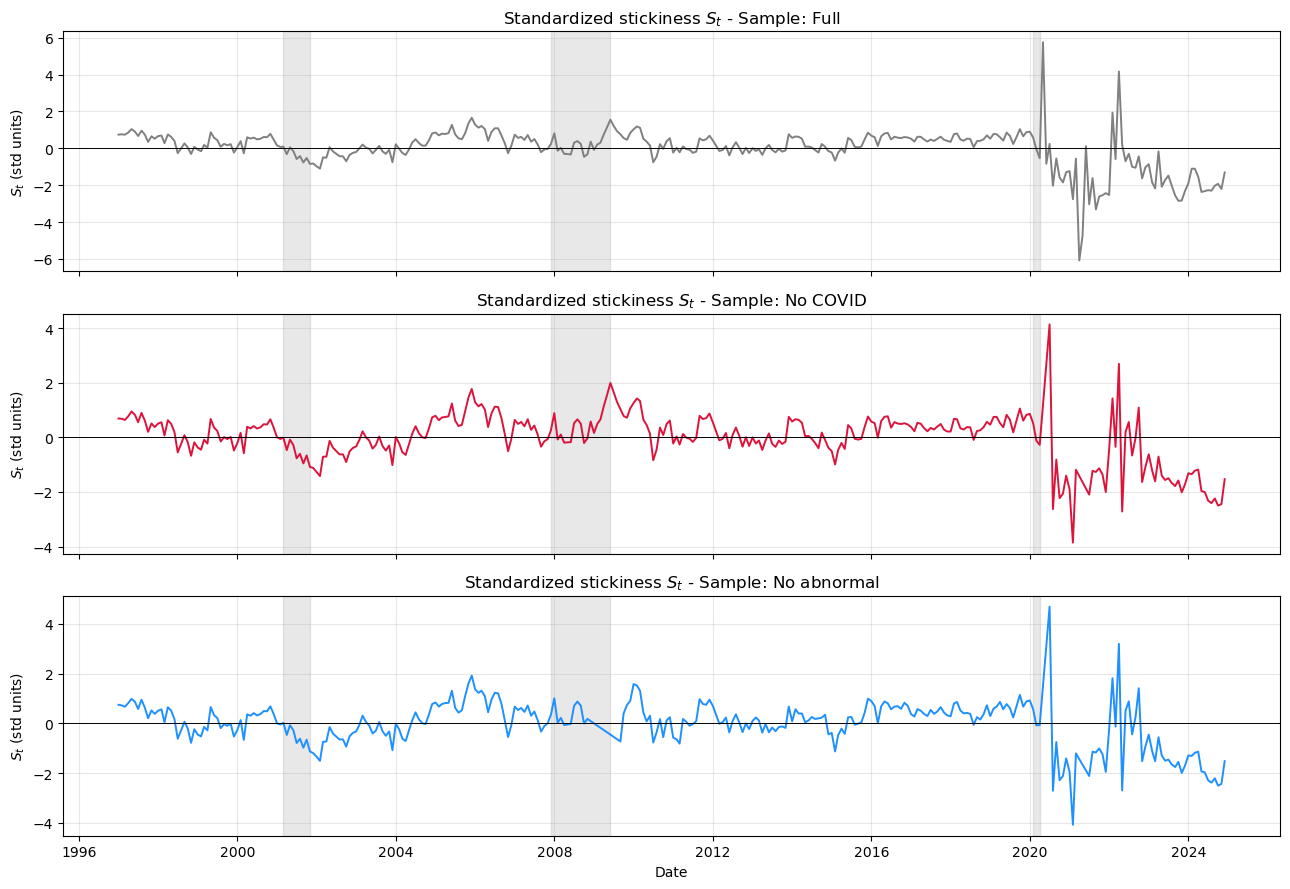

In [14]:
# Plot the three S_t series with NBER recession shading
nber = [('2001-03-01','2001-11-01'), ('2007-12-01','2009-06-01'), ('2020-02-01','2020-04-01')]
colors = {'Full':'gray', 'No COVID':'crimson', 'No abnormal':'dodgerblue'}

fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)
for ax, (name, r) in zip(axes, results.items()):
    ax.plot(r.index, r['S'], color=colors[name], linewidth=1.4)
    ax.axhline(0, color='black', linewidth=0.7)
    ax.set_title(f'Standardized stickiness $S_t$ - Sample: {name}')
    ax.set_ylabel(r'$S_t$ (std units)')
    ax.grid(True, alpha=0.3)
    for s, e in nber:
        ax.axvspan(pd.Timestamp(s), pd.Timestamp(e), color='gray', alpha=0.18)
axes[-1].set_xlabel('Date'); plt.tight_layout()
plt.savefig(FIG_DIR / 'v3_stickiness_three_samples.png', dpi=150, bbox_inches='tight')
plt.show()

## Stage 5 - Predictive regressions

For each horizon $h \in \{1, 3, 6\}$, regress real PCE durables growth at $t+h$ on the LASSO
rational forecast and the subjective belief:

$$\Delta c_{t+h} = \alpha + \beta_1 \hat{c}_t + \beta_2 \text{UMSBMQ}_t + \gamma' X_t + \varepsilon_{t+h}$$

**The stickiness test is $\beta_2$.** If beliefs were perfectly rational, they would be redundant
once we control for $\hat{c}_t$ and macro controls ? implying $\beta_2 = 0$. A significant
$\beta_2$ indicates beliefs carry behaviorally relevant information beyond fundamentals.

The **asymmetric variant** splits the belief into deviations above and below its sample mean,
to test the pessimism-specific prediction:

$$\Delta c_{t+h} = \alpha + \beta_1 \hat{c}_t + \beta^{-}(\text{UMSBMQ}_t - \mu)^{-} + \beta^{+}(\text{UMSBMQ}_t - \mu)^{+} + \gamma' X_t + \varepsilon_{t+h}$$

Theory predicts $\beta^{-} < 0$ and $\beta^{+} \approx 0$.

Newey-West HAC SEs with maxlags = h.


In [15]:
# Build reg_data: outcomes (durables real, non-durables nominal), LASSO forecast, belief, controls
controls_cols = ['UnemploymentRate', 'CPI_YoY', 'Treasury10Y']

def build_reg_data(name):
    r = results[name]
    d = pd.DataFrame({
        'PCE_Durables_Real_YoY':     df.loc[r.index, TARGET],
        'PCE_NonDurables_YoY':       pcnd_m.loc[r.index, 'PCE_NonDurables_YoY'] if all(i in pcnd_m.index for i in r.index) else np.nan,
        'c_hat':                     r['c_hat'],
        'UMSBMQ':                    r['B_subjective'],
    })
    # Use a safer non-durables join:
    d['PCE_NonDurables_YoY'] = pcnd_m['PCE_NonDurables_YoY'].reindex(r.index)
    for c in controls_cols:
        d[c] = df.loc[r.index, c]
    return d

In [16]:
def regress_symmetric(reg_data, outcome_col, h):
    """Spending(t+h) on c_hat + UMSBMQ + controls + lag_y."""
    d = pd.DataFrame({
        'y':       reg_data[outcome_col].shift(-h),
        'c_hat':   reg_data['c_hat'],
        'UMSBMQ':  reg_data['UMSBMQ'],
    })
    for c in controls_cols: d[c] = reg_data[c]
    d['lag_y'] = reg_data[outcome_col]
    d = d.dropna()
    X = sm.add_constant(d.drop(columns='y'))
    return sm.OLS(d['y'], X).fit(cov_type='HAC', cov_kwds={'maxlags': h})

def regress_asymmetric(reg_data, outcome_col, h):
    """Spending(t+h) on c_hat + (UMSBMQ-mu)^- + (UMSBMQ-mu)^+ + controls + lag_y."""
    mu = reg_data['UMSBMQ'].mean()
    dev = reg_data['UMSBMQ'] - mu
    d = pd.DataFrame({
        'y':         reg_data[outcome_col].shift(-h),
        'c_hat':     reg_data['c_hat'],
        'UMSBMQ_neg': dev.clip(upper=0),
        'UMSBMQ_pos': dev.clip(lower=0),
    })
    for c in controls_cols: d[c] = reg_data[c]
    d['lag_y'] = reg_data[outcome_col]
    d = d.dropna()
    X = sm.add_constant(d.drop(columns='y'))
    return sm.OLS(d['y'], X).fit(cov_type='HAC', cov_kwds={'maxlags': h})

In [17]:
# Run all symmetric regressions
rows_sym = []
for name in samples:
    reg = build_reg_data(name)
    for outc_label, outc_col in [('Durables (REAL)','PCE_Durables_Real_YoY'),
                                  ('Non-durables (placebo)','PCE_NonDurables_YoY')]:
        for h in [1, 3, 6]:
            m = regress_symmetric(reg, outc_col, h)
            rows_sym.append({'sample': name, 'outcome': outc_label, 'h': h,
                             'beta_UMSBMQ': m.params['UMSBMQ'], 'se_UMSBMQ': m.bse['UMSBMQ'],
                             'p_UMSBMQ':    m.pvalues['UMSBMQ'], 't_UMSBMQ':  m.tvalues['UMSBMQ'],
                             'beta_chat':   m.params['c_hat'],   'p_chat':    m.pvalues['c_hat'],
                             'R2': m.rsquared, 'n': int(m.nobs)})

rdf_sym = pd.DataFrame(rows_sym)
rdf_sym.to_csv(OUT_DIR / 'v3_predictive_symmetric.csv', index=False)

print("SYMMETRIC: beta_2 on UMSBMQ (the stickiness consequence test)")
print(f"{'Sample':14s} {'Outcome':24s} {'h':>3s} | {'beta_UMSBMQ':>12s} {'SE':>8s} {'p':>8s} | {'R2':>6s} {'N':>4s}")
print('-' * 88)
for r in rows_sym:
    sig = '***' if r['p_UMSBMQ']<0.01 else '**' if r['p_UMSBMQ']<0.05 else '*' if r['p_UMSBMQ']<0.10 else ''
    print(f"{r['sample']:14s} {r['outcome']:24s} {r['h']:>3d} | "
          f"{r['beta_UMSBMQ']:>+12.4f} {r['se_UMSBMQ']:>8.4f} {r['p_UMSBMQ']:>6.3f}{sig:3s} | "
          f"{r['R2']:>6.3f} {r['n']:>4d}")

SYMMETRIC: beta_2 on UMSBMQ (the stickiness consequence test)
Sample         Outcome                    h |  beta_UMSBMQ       SE        p |     R2    N
----------------------------------------------------------------------------------------
Full           Durables (REAL)            1 |      -0.0034   0.0188  0.858    |  0.604  335
Full           Durables (REAL)            3 |      +0.0044   0.0310  0.887    |  0.231  333
Full           Durables (REAL)            6 |      +0.0146   0.0350  0.677    |  0.163  330
Full           Non-durables (placebo)     1 |      -0.0032   0.0043  0.460    |  0.862  335
Full           Non-durables (placebo)     3 |      -0.0264   0.0122  0.031**  |  0.662  333
Full           Non-durables (placebo)     6 |      -0.0398   0.0156  0.011**  |  0.488  330
No COVID       Durables (REAL)            1 |      -0.0098   0.0158  0.534    |  0.530  330
No COVID       Durables (REAL)            3 |      +0.0051   0.0211  0.811    |  0.327  328
No COVID       Durable

In [18]:
# Run all asymmetric regressions
rows_asym = []
for name in samples:
    reg = build_reg_data(name)
    for outc_label, outc_col in [('Durables (REAL)','PCE_Durables_Real_YoY'),
                                  ('Non-durables (placebo)','PCE_NonDurables_YoY')]:
        for h in [1, 3, 6]:
            m = regress_asymmetric(reg, outc_col, h)
            rows_asym.append({'sample': name, 'outcome': outc_label, 'h': h,
                'beta_neg': m.params['UMSBMQ_neg'], 'se_neg': m.bse['UMSBMQ_neg'], 'p_neg': m.pvalues['UMSBMQ_neg'],
                'beta_pos': m.params['UMSBMQ_pos'], 'se_pos': m.bse['UMSBMQ_pos'], 'p_pos': m.pvalues['UMSBMQ_pos'],
                'R2': m.rsquared, 'n': int(m.nobs)})

rdf_asym = pd.DataFrame(rows_asym)
rdf_asym.to_csv(OUT_DIR / 'v3_predictive_asymmetric.csv', index=False)

print("ASYMMETRIC: pessimism (beta_neg) vs optimism (beta_pos) on UMSBMQ deviations from mean")
print(f"{'Sample':14s} {'Outcome':24s} {'h':>3s} | {'beta_neg':>10s} {'p_neg':>7s} | {'beta_pos':>10s} {'p_pos':>7s}")
print('-' * 92)
for r in rows_asym:
    sn = '***' if r['p_neg']<0.01 else '**' if r['p_neg']<0.05 else '*' if r['p_neg']<0.10 else ''
    sp = '***' if r['p_pos']<0.01 else '**' if r['p_pos']<0.05 else '*' if r['p_pos']<0.10 else ''
    print(f"{r['sample']:14s} {r['outcome']:24s} {r['h']:>3d} | "
          f"{r['beta_neg']:>+10.4f} {r['p_neg']:>5.3f}{sn:3s} | "
          f"{r['beta_pos']:>+10.4f} {r['p_pos']:>5.3f}{sp:3s}")

ASYMMETRIC: pessimism (beta_neg) vs optimism (beta_pos) on UMSBMQ deviations from mean
Sample         Outcome                    h |   beta_neg   p_neg |   beta_pos   p_pos
--------------------------------------------------------------------------------------------
Full           Durables (REAL)            1 |    -0.0193 0.453    |    +0.0298 0.404   
Full           Durables (REAL)            3 |    -0.0025 0.951    |    +0.0186 0.718   
Full           Durables (REAL)            6 |    -0.0213 0.733    |    +0.0844 0.263   
Full           Non-durables (placebo)     1 |    -0.0101 0.083*   |    +0.0122 0.437   
Full           Non-durables (placebo)     3 |    -0.0408 0.015**  |    +0.0049 0.829   
Full           Non-durables (placebo)     6 |    -0.0658 0.003*** |    +0.0140 0.582   
No COVID       Durables (REAL)            1 |    -0.0540 0.087*   |    +0.0806 0.047** 
No COVID       Durables (REAL)            3 |    +0.0020 0.948    |    +0.0112 0.808   
No COVID       Durables (REAL)

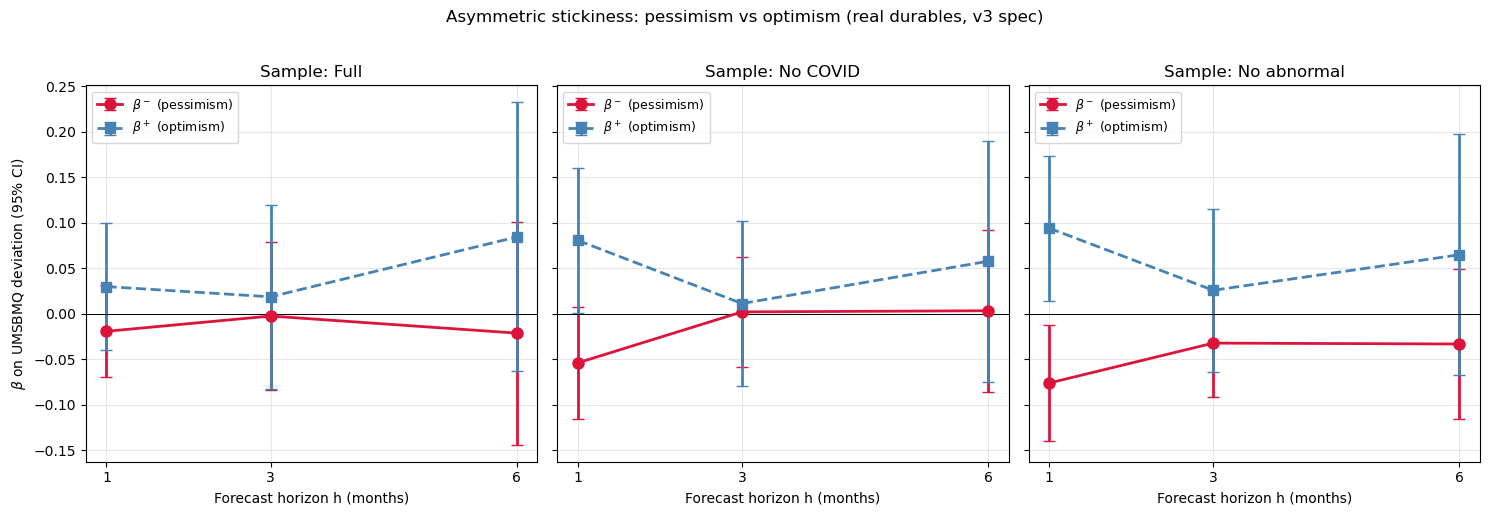

In [ ]:
                    # Plot asymmetric beta by horizon for real durables (the main result)
horizons = [1, 3, 6]
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
for ax, name in zip(axes, samples):
    sub = rdf_asym[(rdf_asym['sample']==name) & (rdf_asym['outcome']=='Durables (REAL)')].sort_values('h')
    ax.errorbar(sub['h'], sub['beta_neg'], yerr=1.96*sub['se_neg'], fmt='o-', capsize=4,
                color='crimson', label=r'$\beta^-$ (pessimism)', linewidth=2, markersize=8)
    ax.errorbar(sub['h'], sub['beta_pos'], yerr=1.96*sub['se_pos'], fmt='s--', capsize=4,
                color='steelblue', label=r'$\beta^+$ (optimism)', linewidth=2, markersize=7)
    ax.axhline(0, color='black', linewidth=0.7)
    ax.set_xticks(horizons); ax.set_xlabel('Forecast horizon h (months)')
    ax.set_title(f'Sample: {name}')
    ax.grid(True, alpha=0.3); ax.legend(fontsize=9)
axes[0].set_ylabel(r'$\beta$ on UMSBMQ deviation (95% CI)')
plt.suptitle('Asymmetric stickiness: pessimism vs optimism (real durables, v3 spec)', y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / 'v3_asymmetric_real_durables.png', dpi=150, bbox_inches='tight')
plt.show()

                            ## Takeaways

In this v3 specification:
- The **rational benchmark $\hat{c}_t$** is anchored to *realized* spending behavior (Du et al. spirit), not to beliefs.
- **Stickiness** is reported descriptively as a standardized z-score gap between the subjective belief and the rational forecast.
- The **formal test** of "stickiness has consequences" is whether $\beta_2$ (or $\beta^-$ in the asymmetric variant) is significant in the predictive regression of future spending on $\hat{c}_t$ and UMSBMQ.
- All results are reported across three samples (Full / No COVID / No abnormal) for robustness.

This methodology is more faithful to Du et al. (2025) than v1/v2 because the LASSO targets the realized outcome rather than the survey itself, avoiding the circularity where the model partially absorbs sticky beliefs into its fitted values.


## Stage 5c - Direct stickiness regression

Cleaner specification using $S_t = z(\text{UMSBMQ}_t) - z(\hat c_t)$ as a single explicit regressor instead of the joint $(\text{UMSBMQ}_t, \hat c_t)$ parameterization.

**Symmetric:**

$$\Delta C_{t+h} = \alpha + \beta_S \cdot S_t + \gamma'\, X_t + \phi \cdot \Delta C_t + \varepsilon_{t+h}$$

**Asymmetric** (since $S_t$ is z-scored, its mean is ~0, so the split is at zero):

$$\Delta C_{t+h} = \alpha + \beta^-_S \cdot S^-_t + \beta^+_S \cdot S^+_t + \gamma'\, X_t + \phi \cdot \Delta C_t + \varepsilon_{t+h}$$

Where $S^-_t = \min(S_t, 0)$ (pessimism vs benchmark) and $S^+_t = \max(S_t, 0)$ (optimism vs benchmark).

Outcomes: real durables (main) and nominal non-durables (placebo). HAC SEs, maxlags = h.

In [20]:
# Stage 5c - Direct stickiness regression: PCE ~ S_t (symmetric + asymmetric + placebo)

def build_reg_data_S(name):
    r = results[name]
    d = pd.DataFrame({
        'PCE_Durables_Real_YoY': df.loc[r.index, TARGET],
        'PCE_NonDurables_YoY':   pcnd_m['PCE_NonDurables_YoY'].reindex(r.index),
        'S':                     r['S'],
    })
    for c in controls_cols:
        d[c] = df.loc[r.index, c]
    return d

def regress_S_sym(reg_data, outcome_col, h):
    d = pd.DataFrame({
        'y': reg_data[outcome_col].shift(-h),
        'S': reg_data['S'],
    })
    for c in controls_cols: d[c] = reg_data[c]
    d['lag_y'] = reg_data[outcome_col]
    d = d.dropna()
    X = sm.add_constant(d.drop(columns='y'))
    return sm.OLS(d['y'], X).fit(cov_type='HAC', cov_kwds={'maxlags': h})

def regress_S_asym(reg_data, outcome_col, h):
    d = pd.DataFrame({
        'y':     reg_data[outcome_col].shift(-h),
        'S_neg': reg_data['S'].clip(upper=0),
        'S_pos': reg_data['S'].clip(lower=0),
    })
    for c in controls_cols: d[c] = reg_data[c]
    d['lag_y'] = reg_data[outcome_col]
    d = d.dropna()
    X = sm.add_constant(d.drop(columns='y'))
    return sm.OLS(d['y'], X).fit(cov_type='HAC', cov_kwds={'maxlags': h})

rows_S_sym, rows_S_asym = [], []
for name in samples:
    reg = build_reg_data_S(name)
    for outc_label, outc_col in [('Durables (REAL)','PCE_Durables_Real_YoY'),
                                  ('Non-durables (placebo)','PCE_NonDurables_YoY')]:
        for h in [1, 3, 6]:
            m = regress_S_sym(reg, outc_col, h)
            rows_S_sym.append({'sample': name, 'outcome': outc_label, 'h': h,
                               'beta_S': m.params['S'], 'se_S': m.bse['S'],
                               'p_S': m.pvalues['S'], 't_S': m.tvalues['S'],
                               'R2': m.rsquared, 'n': int(m.nobs)})
            ma = regress_S_asym(reg, outc_col, h)
            rows_S_asym.append({'sample': name, 'outcome': outc_label, 'h': h,
                                'beta_neg': ma.params['S_neg'], 'se_neg': ma.bse['S_neg'], 'p_neg': ma.pvalues['S_neg'],
                                'beta_pos': ma.params['S_pos'], 'se_pos': ma.bse['S_pos'], 'p_pos': ma.pvalues['S_pos'],
                                'R2': ma.rsquared, 'n': int(ma.nobs)})

rdf_S_sym  = pd.DataFrame(rows_S_sym);  rdf_S_sym.to_csv(OUT_DIR  / 'v3_predictive_S_symmetric.csv',  index=False)
rdf_S_asym = pd.DataFrame(rows_S_asym); rdf_S_asym.to_csv(OUT_DIR / 'v3_predictive_S_asymmetric.csv', index=False)

print('=' * 90)
print('DIRECT STICKINESS REGRESSION (SYMMETRIC):  y_{t+h} = a + b*S_t + controls + lag_y')
print('=' * 90)
print(f"{'Sample':14s} {'Outcome':24s} {'h':>3s} | {'beta_S':>10s} {'SE':>8s} {'p':>8s} | {'R2':>6s} {'N':>4s}")
print('-' * 90)
for r in rows_S_sym:
    sig = '***' if r['p_S']<0.01 else '**' if r['p_S']<0.05 else '*' if r['p_S']<0.10 else ''
    print(f"{r['sample']:14s} {r['outcome']:24s} {r['h']:>3d} | "
          f"{r['beta_S']:>+10.4f} {r['se_S']:>8.4f} {r['p_S']:>6.3f}{sig:3s} | "
          f"{r['R2']:>6.3f} {r['n']:>4d}")

print()
print('=' * 110)
print('DIRECT STICKINESS REGRESSION (ASYMMETRIC):  y_{t+h} = a + b_neg*S^- + b_pos*S^+ + controls + lag_y')
print('=' * 110)
print(f"{'Sample':14s} {'Outcome':24s} {'h':>3s} | {'beta_neg':>10s} {'p_neg':>7s} | {'beta_pos':>10s} {'p_pos':>7s} | {'R2':>6s} {'N':>4s}")
print('-' * 110)
for r in rows_S_asym:
    sig_n = '***' if r['p_neg']<0.01 else '**' if r['p_neg']<0.05 else '*' if r['p_neg']<0.10 else ''
    sig_p = '***' if r['p_pos']<0.01 else '**' if r['p_pos']<0.05 else '*' if r['p_pos']<0.10 else ''
    print(f"{r['sample']:14s} {r['outcome']:24s} {r['h']:>3d} | "
          f"{r['beta_neg']:>+10.4f} {r['p_neg']:>5.3f}{sig_n:3s} | "
          f"{r['beta_pos']:>+10.4f} {r['p_pos']:>5.3f}{sig_p:3s} | "
          f"{r['R2']:>6.3f} {r['n']:>4d}")

print()
print('Saved -> outputs/v3_predictive_S_symmetric.csv, outputs/v3_predictive_S_asymmetric.csv')

DIRECT STICKINESS REGRESSION (SYMMETRIC):  y_{t+h} = a + b*S_t + controls + lag_y
Sample         Outcome                    h |     beta_S       SE        p |     R2    N
------------------------------------------------------------------------------------------
Full           Durables (REAL)            1 |    +0.1721   0.4890  0.725    |  0.602  335
Full           Durables (REAL)            3 |    +0.0502   0.5211  0.923    |  0.231  333
Full           Durables (REAL)            6 |    +0.2741   0.5717  0.632    |  0.162  330
Full           Non-durables (placebo)     1 |    -0.1115   0.0675  0.099*   |  0.862  335
Full           Non-durables (placebo)     3 |    -0.1199   0.1964  0.541    |  0.646  333
Full           Non-durables (placebo)     6 |    -0.4293   0.2299  0.062*   |  0.472  330
No COVID       Durables (REAL)            1 |    -1.0403   0.6012  0.084*   |  0.507  330
No COVID       Durables (REAL)            3 |    -0.5699   0.3857  0.140    |  0.310  328
No COVID       Dur

In [21]:
# Stickiness regression: spending on the full S_t (no split)

def build_reg_data_S(name):
    r = results[name]
    d = pd.DataFrame({
        'PCE_Durables_Real_YoY': df.loc[r.index, TARGET],
        'PCE_NonDurables_YoY':   pcnd_m['PCE_NonDurables_YoY'].reindex(r.index),
        'S':                     r['S'],
    })
    for c in controls_cols:
        d[c] = df.loc[r.index, c]
    return d


def regress_stickiness(reg_data, outcome_col, h):
    """y_{t+h} = a + b*S_t + controls + lag_y + eps  (HAC, maxlags=h)"""
    d = pd.DataFrame({
        'y': reg_data[outcome_col].shift(-h),
        'S': reg_data['S'],
    })
    for c in controls_cols:
        d[c] = reg_data[c]
    d['lag_y'] = reg_data[outcome_col]
    d = d.dropna()
    X = sm.add_constant(d.drop(columns='y'))
    return sm.OLS(d['y'], X).fit(cov_type='HAC', cov_kwds={'maxlags': h})


outcomes = [
    ('Durables (REAL)',        'PCE_Durables_Real_YoY'),
    ('Non-durables (placebo)', 'PCE_NonDurables_YoY'),
]
horizons = [1, 3, 6]

rows = []
for name in samples:
    reg = build_reg_data_S(name)
    for outc_label, outc_col in outcomes:
        for h in horizons:
            m = regress_stickiness(reg, outc_col, h)
            rows.append({
                'sample':  name,
                'outcome': outc_label,
                'h':       h,
                'beta_S':  m.params['S'],
                'se_S':    m.bse['S'],
                't_S':     m.tvalues['S'],
                'p_S':     m.pvalues['S'],
                'R2':      m.rsquared,
                'n':       int(m.nobs),
            })

rdf = pd.DataFrame(rows)
rdf.to_csv(OUT_DIR / 'v3_predictive_stickiness.csv', index=False)

SEP = '=' * 92
DIV = '-' * 92
HEADER = (
    f"{'Sample':14s} {'Outcome':24s} {'h':>3s} | "
    f"{'beta_S':>10s} {'SE':>8s} {'t':>6s} {'p':>8s} | "
    f"{'R2':>6s} {'N':>4s}"
)

print(SEP)
print('STICKINESS REGRESSION:  y_{t+h} = a + b*S_t + controls + lag_y     (HAC SE, maxlags=h)')
print(SEP)
print(HEADER)
print(DIV)

for r in rows:
    sig = '***' if r['p_S'] < 0.01 else '**' if r['p_S'] < 0.05 else '*' if r['p_S'] < 0.10 else ''
    print(
        f"{r['sample']:14s} {r['outcome']:24s} {r['h']:>3d} | "
        f"{r['beta_S']:>+10.4f} {r['se_S']:>8.4f} {r['t_S']:>+6.2f} {r['p_S']:>6.3f}{sig:3s} | "
        f"{r['R2']:>6.3f} {r['n']:>4d}"
    )

print('\nSaved -> outputs/v3_predictive_stickiness.csv')

STICKINESS REGRESSION:  y_{t+h} = a + b*S_t + controls + lag_y     (HAC SE, maxlags=h)
Sample         Outcome                    h |     beta_S       SE      t        p |     R2    N
--------------------------------------------------------------------------------------------
Full           Durables (REAL)            1 |    +0.1721   0.4890  +0.35  0.725    |  0.602  335
Full           Durables (REAL)            3 |    +0.0502   0.5211  +0.10  0.923    |  0.231  333
Full           Durables (REAL)            6 |    +0.2741   0.5717  +0.48  0.632    |  0.162  330
Full           Non-durables (placebo)     1 |    -0.1115   0.0675  -1.65  0.099*   |  0.862  335
Full           Non-durables (placebo)     3 |    -0.1199   0.1964  -0.61  0.541    |  0.646  333
Full           Non-durables (placebo)     6 |    -0.4293   0.2299  -1.87  0.062*   |  0.472  330
No COVID       Durables (REAL)            1 |    -1.0403   0.6012  -1.73  0.084*   |  0.507  330
No COVID       Durables (REAL)            3 |

## Stage 5d - Du-style belief elasticity / underreaction test

Following Du, Monninger, Qiu & Wang (2025, Eq. 6), we test whether subjective beliefs adjust sluggishly to the rational forecast by regressing the standardized subjective belief on the standardized LASSO benchmark:

$$z(\text{UMSBMQ}_t) = \alpha + \beta \cdot z(\hat c_t) + \varepsilon_t$$

Under rational expectations, $\beta = 1$: beliefs move one-for-one with the rational forecast in standardized units. Under sticky beliefs / underreaction, $\beta < 1$: beliefs adjust by less than the rational benchmark moves.

We report $\hat\beta$, its HAC standard error, and a one-sided test of $H_0: \beta = 1$ against $H_1: \beta < 1$. Run separately on Full / No COVID / No abnormal samples.

In [22]:
# Stage 5d - Du-style underreaction test: z(UMSBMQ) on z(c_hat)
from scipy import stats

rows_du = []
for name in samples:
    r = results[name].dropna(subset=['B_subjective', 'c_hat'])
    z_b = (r['B_subjective'] - r['B_subjective'].mean()) / r['B_subjective'].std()
    z_c = (r['c_hat']        - r['c_hat'].mean())        / r['c_hat'].std()
    X = sm.add_constant(pd.DataFrame({'z_c': z_c}))
    m = sm.OLS(z_b, X).fit(cov_type='HAC', cov_kwds={'maxlags': 3})
    beta  = m.params['z_c']
    se    = m.bse['z_c']
    t_one = (beta - 1) / se                       # H_0: beta = 1
    p_one = stats.norm.cdf(t_one)                 # one-sided: P(Z <= t_one) for beta < 1
    rows_du.append({
        'sample': name,
        'beta':   beta,
        'se':     se,
        't_beta_eq_1': t_one,
        'p_one_sided': p_one,
        'R2':     m.rsquared,
        'n':      int(m.nobs),
    })

du_df = pd.DataFrame(rows_du)
du_df.to_csv(OUT_DIR / 'v3_underreaction_du.csv', index=False)

print('=' * 90)
print('DU-STYLE UNDERREACTION TEST:  z(UMSBMQ_t) = a + beta * z(c_hat_t) + eps')
print('H_0: beta = 1 (rational).  H_1: beta < 1 (underreaction / sticky beliefs).')
print('=' * 90)
print(f"{'Sample':14s} | {'beta':>8s} {'SE':>7s} | {'t(b=1)':>8s} {'p(1-sided)':>11s} | {'R2':>6s} {'N':>4s}")
print('-' * 90)
for r in rows_du:
    sig = '***' if r['p_one_sided']<0.01 else '**' if r['p_one_sided']<0.05 else '*' if r['p_one_sided']<0.10 else ''
    print(f"{r['sample']:14s} | {r['beta']:>+8.3f} {r['se']:>7.3f} | "
          f"{r['t_beta_eq_1']:>+8.2f} {r['p_one_sided']:>9.4f}{sig:3s} | "
          f"{r['R2']:>6.3f} {r['n']:>4d}")
print()
print('Interpretation: beta < 1 with low p-value => beliefs underreact to the rational forecast,')
print('consistent with the sticky-beliefs hypothesis (Du et al. 2025, Eq. 6).')
print()
print('Saved -> outputs/v3_underreaction_du.csv')

DU-STYLE UNDERREACTION TEST:  z(UMSBMQ_t) = a + beta * z(c_hat_t) + eps
H_0: beta = 1 (rational).  H_1: beta < 1 (underreaction / sticky beliefs).
Sample         |     beta      SE |   t(b=1)  p(1-sided) |     R2    N
------------------------------------------------------------------------------------------
Full           |   +0.443   0.109 |    -5.12    0.0000*** |  0.196  336
No COVID       |   +0.600   0.072 |    -5.58    0.0000*** |  0.360  331
No abnormal    |   +0.576   0.078 |    -5.44    0.0000*** |  0.332  322

Interpretation: beta < 1 with low p-value => beliefs underreact to the rational forecast,
consistent with the sticky-beliefs hypothesis (Du et al. 2025, Eq. 6).

Saved -> outputs/v3_underreaction_du.csv


In [23]:
# ── R² and Adj-R² summary for all Stage-5 models ────────────────────────────

outcomes_list = [
    ('Durables (REAL)',        'PCE_Durables_Real_YoY'),
    ('Non-durables (placebo)', 'PCE_NonDurables_YoY'),
]
horizons = [1, 3, 6]

r2_rows = []

for name in samples:
    reg_main = build_reg_data(name)
    reg_S    = build_reg_data_S(name)

    for outc_label, outc_col in outcomes_list:
        for h in horizons:

            # 1. Symmetric: Δc(t+h) ~ c_hat + UMSBMQ + controls + lag_y
            m = regress_symmetric(reg_main, outc_col, h)
            r2_rows.append({
                'spec':    'Symmetric  (β₂ on UMSBMQ)',
                'sample':  name, 'outcome': outc_label, 'h': h,
                'R2':      m.rsquared, 'Adj_R2': m.rsquared_adj, 'n': int(m.nobs),
            })

            # 2. Asymmetric: Δc(t+h) ~ c_hat + UMSBMQ⁻ + UMSBMQ⁺ + controls + lag_y
            m = regress_asymmetric(reg_main, outc_col, h)
            r2_rows.append({
                'spec':    'Asymmetric (β⁻/β⁺ on UMSBMQ dev)',
                'sample':  name, 'outcome': outc_label, 'h': h,
                'R2':      m.rsquared, 'Adj_R2': m.rsquared_adj, 'n': int(m.nobs),
            })

            # 3. Direct S symmetric: Δc(t+h) ~ S_t + controls + lag_y
            m = regress_S_sym(reg_S, outc_col, h)
            r2_rows.append({
                'spec':    'Direct S   Symmetric  (β on S_t)',
                'sample':  name, 'outcome': outc_label, 'h': h,
                'R2':      m.rsquared, 'Adj_R2': m.rsquared_adj, 'n': int(m.nobs),
            })

            # 4. Direct S asymmetric: Δc(t+h) ~ S⁻ + S⁺ + controls + lag_y
            m = regress_S_asym(reg_S, outc_col, h)
            r2_rows.append({
                'spec':    'Direct S   Asymmetric (β⁻/β⁺ on S)',
                'sample':  name, 'outcome': outc_label, 'h': h,
                'R2':      m.rsquared, 'Adj_R2': m.rsquared_adj, 'n': int(m.nobs),
            })

            # 5. Stickiness regression: Δc(t+h) ~ S_t + controls + lag_y  [v3_predictive_stickiness]
            m = regress_stickiness(reg_S, outc_col, h)
            r2_rows.append({
                'spec':    'Stickiness (β on S_t, no split)',
                'sample':  name, 'outcome': outc_label, 'h': h,
                'R2':      m.rsquared, 'Adj_R2': m.rsquared_adj, 'n': int(m.nobs),
            })

r2_df = pd.DataFrame(r2_rows)
r2_df.to_csv(OUT_DIR / 'v3_r2_summary.csv', index=False)

# ── Print ─────────────────────────────────────────────────────────────────────
SEP = '=' * 96
DIV = '-' * 96
HDR = f"{'Sample':14s} {'Outcome':26s} {'h':>3s} | {'R²':>8s} {'Adj-R²':>8s} | {'N':>4s}"

for spec, grp in r2_df.groupby('spec', sort=False):
    print(SEP)
    print(f'  {spec}')
    print(SEP)
    print(HDR)
    print(DIV)
    for _, row in grp.iterrows():
        print(
            f"{row['sample']:14s} {row['outcome']:26s} {int(row['h']):>3d} | "
            f"{row['R2']:>8.4f} {row['Adj_R2']:>8.4f} | {int(row['n']):>4d}"
        )
    print()

print('Saved -> outputs/v3_r2_summary.csv')

  Symmetric  (β₂ on UMSBMQ)
Sample         Outcome                      h |       R²   Adj-R² |    N
------------------------------------------------------------------------------------------------
Full           Durables (REAL)              1 |   0.6039   0.5967 |  335
Full           Durables (REAL)              3 |   0.2309   0.2167 |  333
Full           Durables (REAL)              6 |   0.1626   0.1470 |  330
Full           Non-durables (placebo)       1 |   0.8616   0.8590 |  335
Full           Non-durables (placebo)       3 |   0.6625   0.6562 |  333
Full           Non-durables (placebo)       6 |   0.4883   0.4788 |  330
No COVID       Durables (REAL)              1 |   0.5301   0.5213 |  330
No COVID       Durables (REAL)              3 |   0.3265   0.3140 |  328
No COVID       Durables (REAL)              6 |   0.2183   0.2035 |  325
No COVID       Non-durables (placebo)       1 |   0.8701   0.8677 |  330
No COVID       Non-durables (placebo)       3 |   0.7343   0.7294 |  328

In [25]:
  def stars(p):
      return '***' if p < 0.01 else '**' if p < 0.05 else '*' if p < 0.10 else ''

  for outc_label, outc_col in [('Durables (REAL)',        'PCE_Durables_Real_YoY'),
                                ('Non-durables (placebo)', 'PCE_NonDurables_YoY')]:
      print('=' * 95)
      print(f'FULL SYMMETRIC REGRESSION:  {outc_label}')
      print('  y_{t+h} = a + b_chat*c_hat + b_UMSBMQ*UMSBMQ + controls + lag_y')
      print('=' * 95)
      for name in samples:
          reg = build_reg_data(name)
          for h in [1, 3, 6]:
              m = regress_symmetric(reg, outc_col, h)
              print(f'\n--- {name},  h = {h}  (N = {int(m.nobs)},  R2 = {m.rsquared:.3f}) ---')
              print(f"{'Variable':18s} {'beta':>10s} {'SE':>10s} {'t':>7s} {'p':>8s} {'sig':>4s}")
              for var in m.params.index:
                  b   = m.params[var]
                  se  = m.bse[var]
                  t   = m.tvalues[var]
                  p   = m.pvalues[var]
                  print(f"{var:18s} {b:>+10.4f} {se:>10.4f} {t:>+7.2f} {p:>8.3f} {stars(p):>4s}")
      print()

  print('=' * 95)
  print('Significance: *** p<0.01   ** p<0.05   * p<0.10  (two-sided, HAC SE, maxlags = h)')
  print('=' * 95)

FULL SYMMETRIC REGRESSION:  Durables (REAL)
  y_{t+h} = a + b_chat*c_hat + b_UMSBMQ*UMSBMQ + controls + lag_y

--- Full,  h = 1  (N = 335,  R2 = 0.604) ---
Variable                 beta         SE       t        p  sig
const                 +3.7071     3.6859   +1.01    0.315     
c_hat                 -0.0833     0.1364   -0.61    0.541     
UMSBMQ                -0.0034     0.0188   -0.18    0.858     
UnemploymentRate      -0.1603     0.2186   -0.73    0.463     
CPI_YoY               -0.5855     0.2826   -2.07    0.038   **
Treasury10Y           +0.1536     0.2180   +0.70    0.481     
lag_y                 +0.7766     0.1311   +5.92    0.000  ***

--- Full,  h = 3  (N = 333,  R2 = 0.231) ---
Variable                 beta         SE       t        p  sig
const                 +4.9572     6.4830   +0.76    0.444     
c_hat                 +0.0041     0.0940   +0.04    0.966     
UMSBMQ                +0.0044     0.0310   +0.14    0.887     
UnemploymentRate      -0.1565     0.2290  